<a href="https://colab.research.google.com/github/Pushkarsinghs/indian_stock-analysis/blob/main/05_forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📈 Indian Stock Market Analysis
## Notebook 5: Price Forecasting

This notebook builds two forecasting models for NIFTY 50 stocks:
1. Facebook Prophet — trend + seasonality based forecasting
2. LSTM Neural Network — deep learning based price prediction

**Output:** 30-day price forecasts for all stocks + Power BI ready CSV

In [14]:
from google.colab import drive
drive.mount('/content/drive')

!pip install prophet pyarrow -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

BASE = '/content/drive/MyDrive/indian_stock_analysis'

print("✅ Libraries ready!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Libraries ready!


In [15]:
# Load technical data from Notebook 2
df = pd.read_parquet(f"{BASE}/data/processed/nifty50_technical.parquet")
df["Date"] = pd.to_datetime(df["Date"])

# Focus on closing prices only
prices = df.pivot_table(index="Date", columns="Ticker", values="Close")
prices = prices.sort_index()

print(f"✅ Data loaded!")
print(f"📊 Shape: {prices.shape}")
print(f"📅 Date range: {prices.index.min().date()} → {prices.index.max().date()}")
print(f"📈 Stocks: {prices.shape[1]}")

✅ Data loaded!
📊 Shape: (250, 49)
📅 Date range: 2025-06-24 → 2026-06-24
📈 Stocks: 49


In [16]:


from prophet import Prophet
from datetime import datetime

all_forecasts  = []
failed_tickers = []

# Load fresh to be safe
df_forecast = pd.read_parquet(f"{BASE}/data/processed/nifty50_technical.parquet")
df_forecast["Date"] = pd.to_datetime(df_forecast["Date"])

# Remove timezone if present
if df_forecast["Date"].dt.tz is not None:
    df_forecast["Date"] = df_forecast["Date"].dt.tz_localize(None)

NIFTY_50 = df_forecast["Ticker"].unique().tolist()
print(f"🔮 Running Prophet forecasts for {len(NIFTY_50)} stocks...\n")

for i, ticker in enumerate(NIFTY_50, 1):
    print(f"  [{i:02d}/{len(NIFTY_50)}] {ticker}...", end=" ")

    try:
        # Prepare data
        stock_data = df_forecast[df_forecast["Ticker"] == ticker][["Date","Close"]].copy()
        stock_data.columns = ["ds", "y"]
        stock_data["ds"]   = pd.to_datetime(stock_data["ds"])
        stock_data         = stock_data.dropna().sort_values("ds")
        stock_data         = stock_data.drop_duplicates(subset=["ds"])

        # Check minimum data requirement
        if len(stock_data) < 60:
            print(f"⚠️  Only {len(stock_data)} rows — skipped")
            failed_tickers.append(ticker)
            continue

        # Build and fit Prophet
        model = Prophet(
            daily_seasonality  = False,
            weekly_seasonality = True,
            yearly_seasonality = True,
            changepoint_prior_scale  = 0.05,
            seasonality_prior_scale  = 10,
            interval_width           = 0.80
        )
        model.fit(stock_data)

        # Forecast 30 business days ahead
        future   = model.make_future_dataframe(periods=30, freq="B")
        forecast = model.predict(future)

        # Clean result
        result_df = forecast[["ds","yhat","yhat_lower","yhat_upper"]].copy()
        result_df.columns = ["Date","Forecast","Lower_CI","Upper_CI"]
        result_df["Ticker"] = ticker
        for col in ["Forecast","Lower_CI","Upper_CI"]:
            result_df[col] = result_df[col].round(2)

        all_forecasts.append(result_df)

        # Print summary
        latest_price  = stock_data["y"].iloc[-1]
        predicted_30d = result_df["Forecast"].iloc[-1]
        change_pct    = round((predicted_30d - latest_price) / latest_price * 100, 2)
        direction     = "📈" if change_pct > 0 else "📉"
        print(f"✅ ₹{latest_price:.0f} → ₹{predicted_30d:.0f} ({change_pct:+.1f}%) {direction}")

    except Exception as e:
        failed_tickers.append(ticker)
        print(f"❌ {e}")

# Combine
if all_forecasts:
    master_forecast = pd.concat(all_forecasts, ignore_index=True)
    print(f"\n✅ Forecasting complete!")
    print(f"📊 Stocks forecasted:    {len(all_forecasts)}")
    print(f"📈 Total forecast rows:  {len(master_forecast):,}")
    if failed_tickers:
        print(f"⚠️  Failed ({len(failed_tickers)}): {failed_tickers}")
else:
    print("❌ No forecasts generated — check the error messages above")

🔮 Running Prophet forecasts for 49 stocks...

  [01/49] ADANIENT.NS... ✅ ₹3070 → ₹2864 (-6.7%) 📉
  [02/49] ADANIPORTS.NS... ✅ ₹1813 → ₹1793 (-1.1%) 📉
  [03/49] APOLLOHOSP.NS... ✅ ₹8574 → ₹8877 (+3.5%) 📈
  [04/49] ASIANPAINT.NS... ✅ ₹2668 → ₹2882 (+8.1%) 📈
  [05/49] AXISBANK.NS... ✅ ₹1384 → ₹1271 (-8.2%) 📉
  [06/49] BAJAJ-AUTO.NS... ✅ ₹9750 → ₹9815 (+0.7%) 📈
  [07/49] BAJAJFINSV.NS... ✅ ₹1780 → ₹1751 (-1.7%) 📉
  [08/49] BAJFINANCE.NS... ✅ ₹991 → ₹965 (-2.6%) 📉
  [09/49] BHARTIARTL.NS... ✅ ₹1877 → ₹1886 (+0.4%) 📈
  [10/49] BPCL.NS... ✅ ₹316 → ₹327 (+3.5%) 📈
  [11/49] BRITANNIA.NS... ✅ ₹5262 → ₹5126 (-2.6%) 📉
  [12/49] CIPLA.NS... ✅ ₹1438 → ₹1447 (+0.6%) 📈
  [13/49] COALINDIA.NS... ✅ ₹442 → ₹431 (-2.5%) 📉
  [14/49] DIVISLAB.NS... ✅ ₹6754 → ₹6570 (-2.7%) 📉
  [15/49] DRREDDY.NS... ✅ ₹1328 → ₹1235 (-7.0%) 📉
  [16/49] EICHERMOT.NS... ✅ ₹7572 → ₹7743 (+2.3%) 📈
  [17/49] GRASIM.NS... ✅ ₹3128 → ₹3113 (-0.5%) 📉
  [18/49] HCLTECH.NS... ✅ ₹1114 → ₹923 (-17.1%) 📉
  [19/49] HDFCBANK.NS... ✅ ₹793 → ₹8

In [17]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.preprocessing import MinMaxScaler

def build_lstm_model(sequence_length=60):
    """Build LSTM neural network architecture"""
    model = Sequential([
        LSTM(64, return_sequences=True,
             input_shape=(sequence_length, 1)),
        Dropout(0.2),
        LSTM(64, return_sequences=False),
        Dropout(0.2),
        Dense(32, activation="relu"),
        Dense(1)
    ])
    model.compile(optimizer="adam", loss="mse")
    return model


def forecast_with_lstm(df, ticker, forecast_days=30, sequence_length=60):
    """Forecast stock price using LSTM neural network"""

    stock_data = df[df["Ticker"] == ticker][["Date","Close"]].copy()
    stock_data = stock_data.dropna().sort_values("Date")

    if len(stock_data) < sequence_length + 30:
        return None

    prices_arr = stock_data["Close"].values.reshape(-1, 1)

    # Scale data to 0-1
    scaler = MinMaxScaler(feature_range=(0, 1))
    scaled = scaler.fit_transform(prices_arr)

    # Create sequences
    X, y = [], []
    for i in range(sequence_length, len(scaled)):
        X.append(scaled[i-sequence_length:i, 0])
        y.append(scaled[i, 0])

    X, y = np.array(X), np.array(y)
    X = X.reshape(X.shape[0], X.shape[1], 1)

    # Train/test split (80/20)
    split   = int(len(X) * 0.8)
    X_train, X_test = X[:split], X[split:]
    y_train, y_test = y[:split], y[split:]

    # Build and train model
    model = build_lstm_model(sequence_length)
    model.fit(
        X_train, y_train,
        epochs=20,
        batch_size=32,
        validation_data=(X_test, y_test),
        verbose=0
    )

    # Forecast next 30 days
    last_sequence = scaled[-sequence_length:]
    predictions   = []

    for _ in range(forecast_days):
        seq        = last_sequence.reshape(1, sequence_length, 1)
        next_price = model.predict(seq, verbose=0)[0][0]
        predictions.append(next_price)
        last_sequence = np.append(last_sequence[1:], [[next_price]], axis=0)

    # Inverse transform
    predictions_actual = scaler.inverse_transform(
        np.array(predictions).reshape(-1, 1)
    ).flatten()

    # Get test predictions for accuracy
    test_predictions = scaler.inverse_transform(
        model.predict(X_test, verbose=0)
    ).flatten()
    actual_test = scaler.inverse_transform(y_test.reshape(-1,1)).flatten()

    # RMSE
    rmse = round(np.sqrt(np.mean((test_predictions - actual_test) ** 2)), 2)

    return {
        "ticker":      ticker,
        "predictions": predictions_actual,
        "rmse":        rmse,
        "last_price":  prices_arr[-1][0]
    }


print("✅ LSTM model architecture ready!")
print(f"   TensorFlow version: {tf.__version__}")

✅ LSTM model architecture ready!
   TensorFlow version: 2.20.0


In [13]:
# Run LSTM on top 5 most traded stocks
# (LSTM is compute-heavy so we pick key stocks)
LSTM_STOCKS = [
    "RELIANCE.NS", "TCS.NS",
    "HDFCBANK.NS", "INFY.NS", "ICICIBANK.NS"
]

lstm_results = []

print("🧠 Running LSTM forecasts (this takes 2-3 mins)...\n")

for ticker in LSTM_STOCKS:
    print(f"  Training LSTM for {ticker}...", end=" ")

    result = forecast_with_lstm(df, ticker, forecast_days=30)

    if result:
        change = round(
            (result["predictions"][-1] - result["last_price"])
            / result["last_price"] * 100, 2
        )
        print(f"✅ RMSE: ₹{result['rmse']} | "
              f"30d forecast: {change:+.1f}%")
        lstm_results.append(result)
    else:
        print("⚠️  Skipped")

print(f"\n✅ LSTM complete for {len(lstm_results)} stocks!")

🧠 Running LSTM forecasts (this takes 2-3 mins)...

  Training LSTM for RELIANCE.NS... ✅ RMSE: ₹42.05 | 30d forecast: +6.5%
  Training LSTM for TCS.NS... ✅ RMSE: ₹104.74 | 30d forecast: +11.3%
  Training LSTM for HDFCBANK.NS... ✅ RMSE: ₹19.69 | 30d forecast: -5.4%
  Training LSTM for INFY.NS... ✅ RMSE: ₹52.51 | 30d forecast: +13.2%
  Training LSTM for ICICIBANK.NS... ✅ RMSE: ₹39.16 | 30d forecast: -1.8%

✅ LSTM complete for 5 stocks!


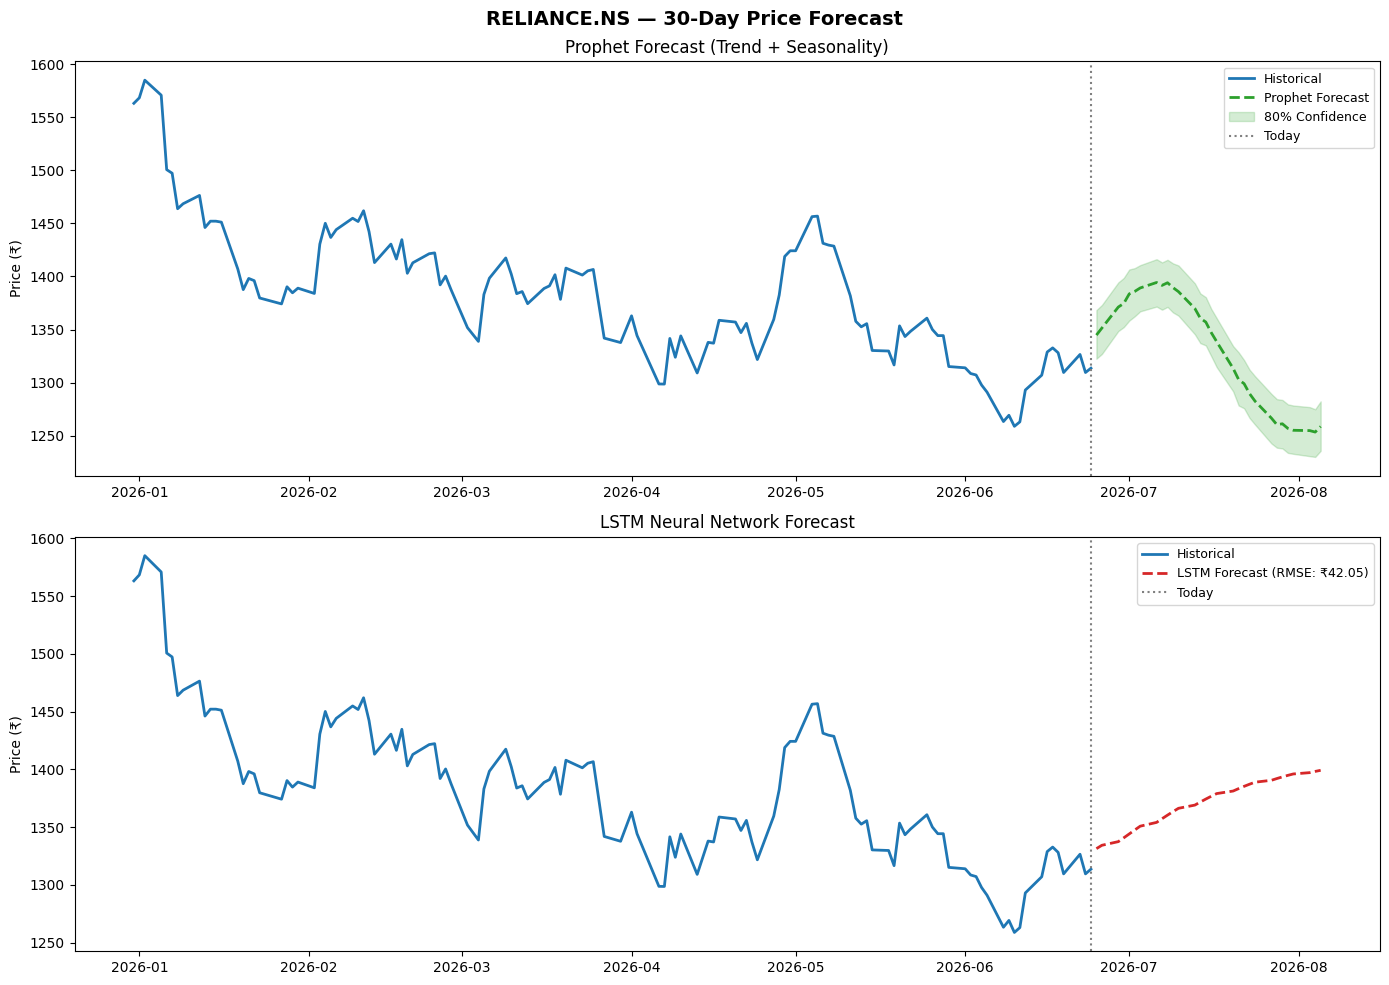

✅ Chart saved for RELIANCE.NS


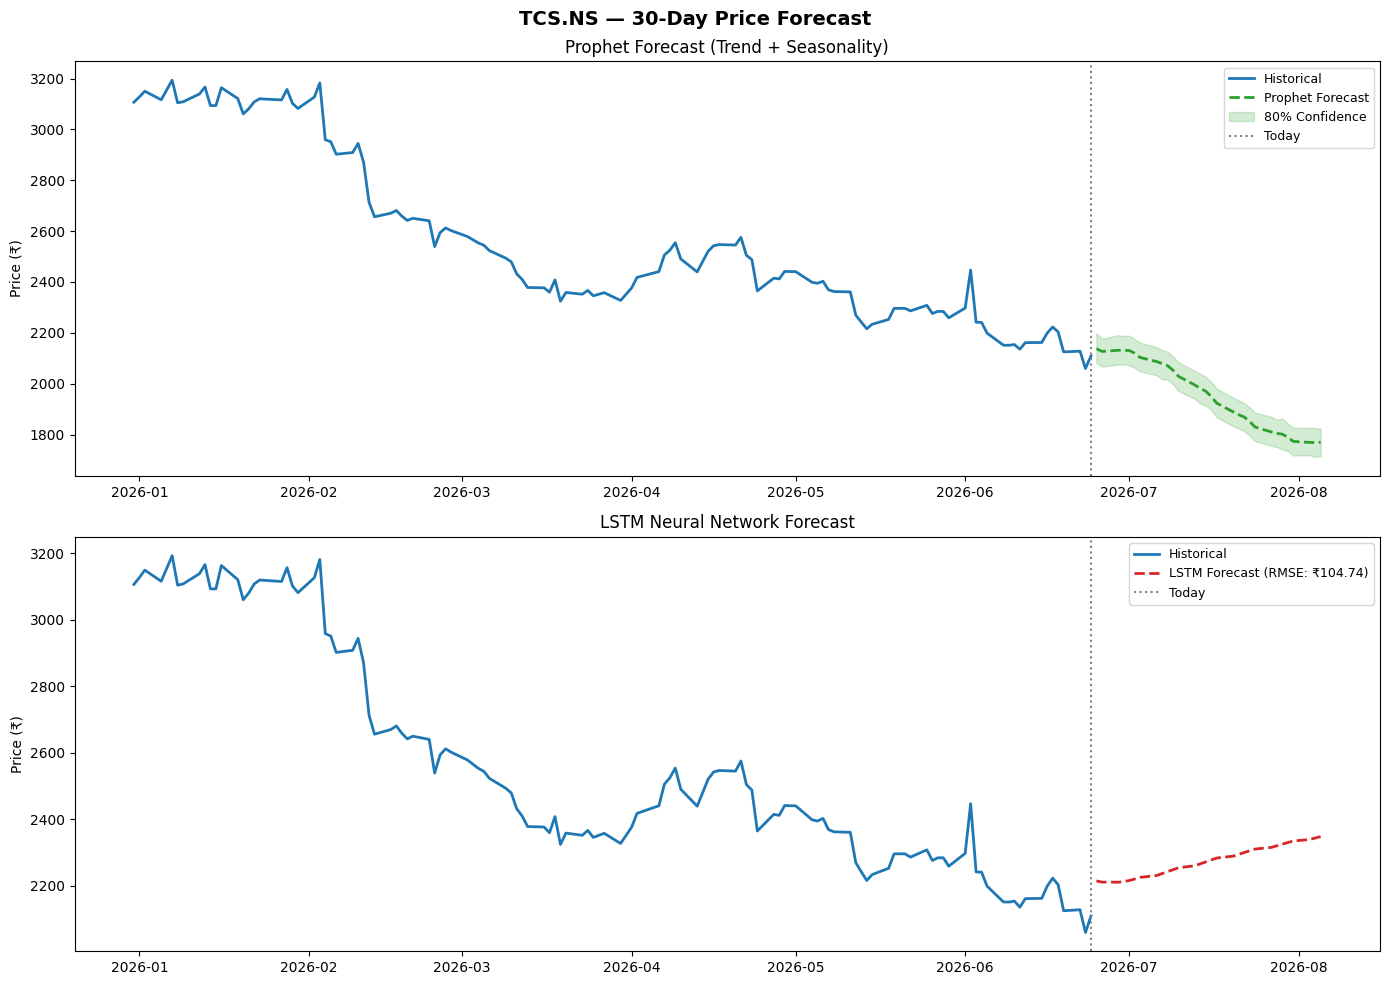

✅ Chart saved for TCS.NS


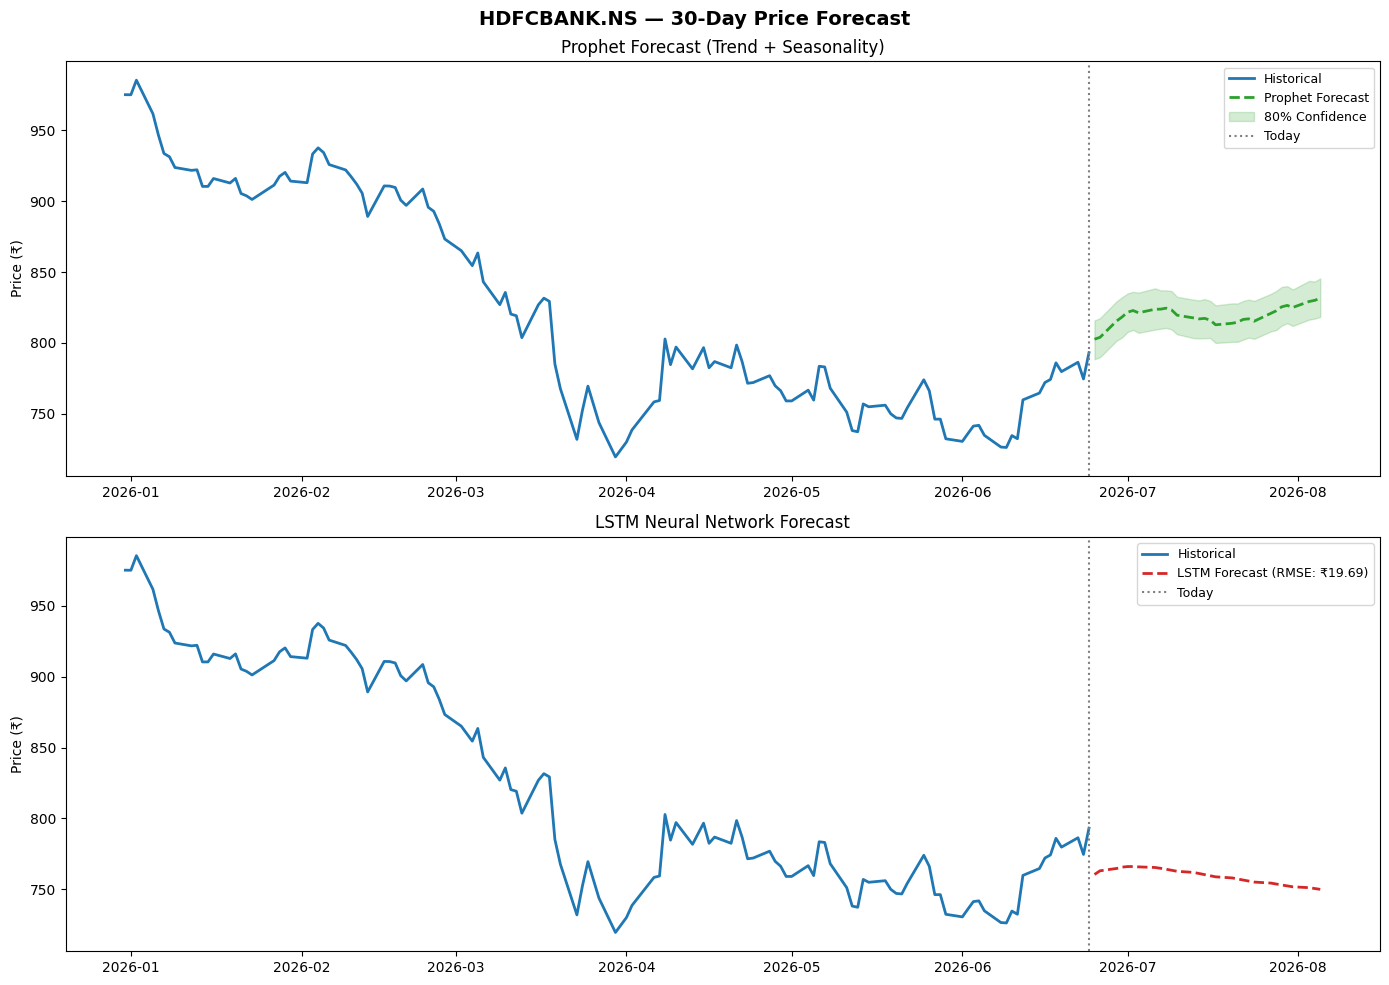

✅ Chart saved for HDFCBANK.NS


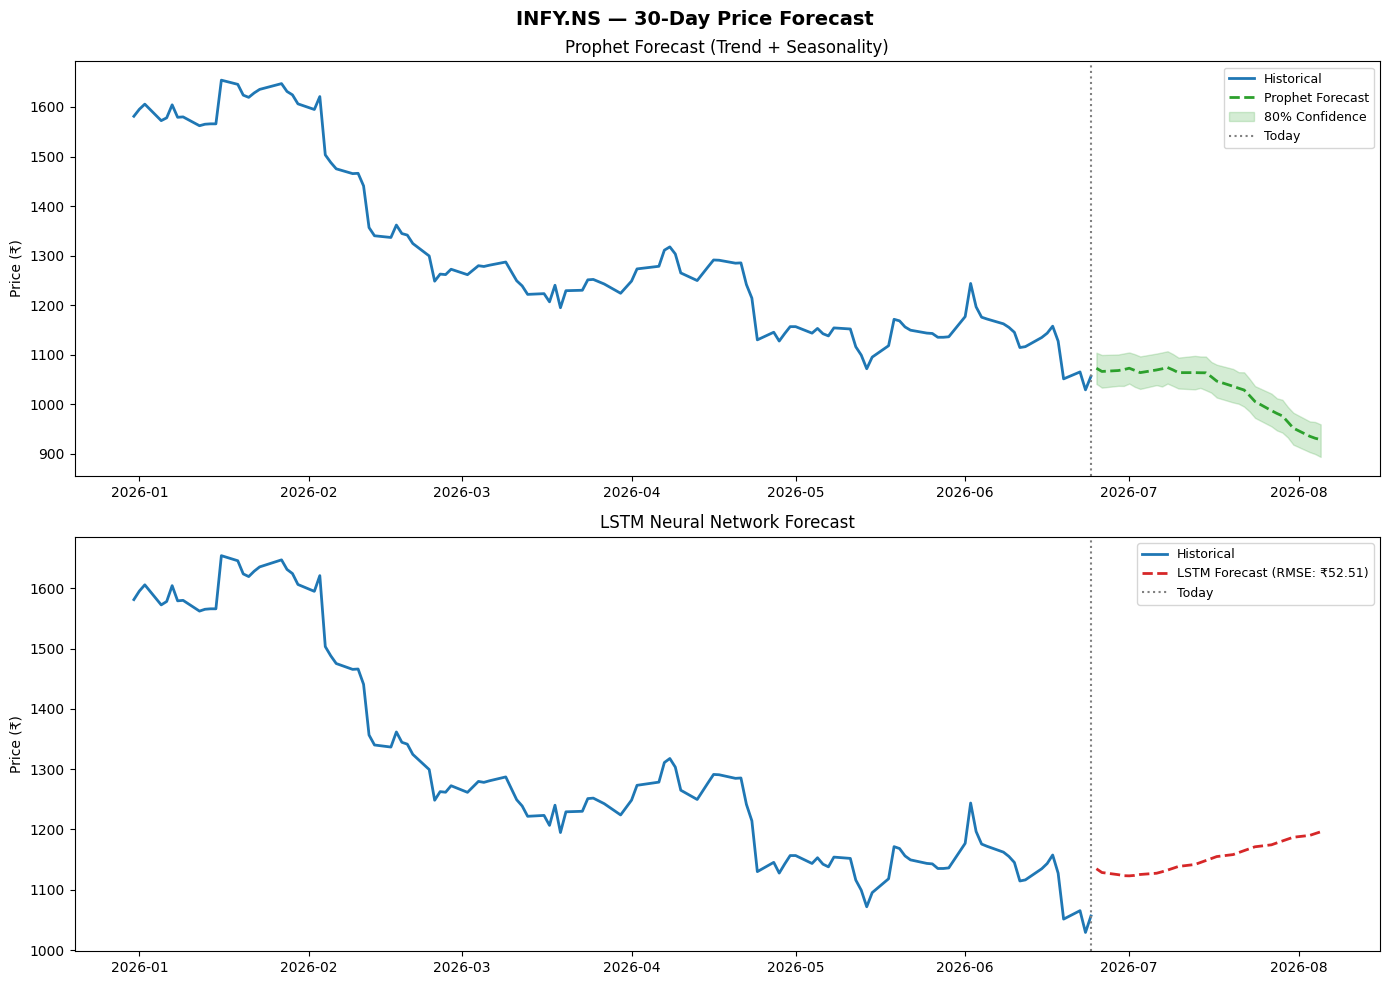

✅ Chart saved for INFY.NS


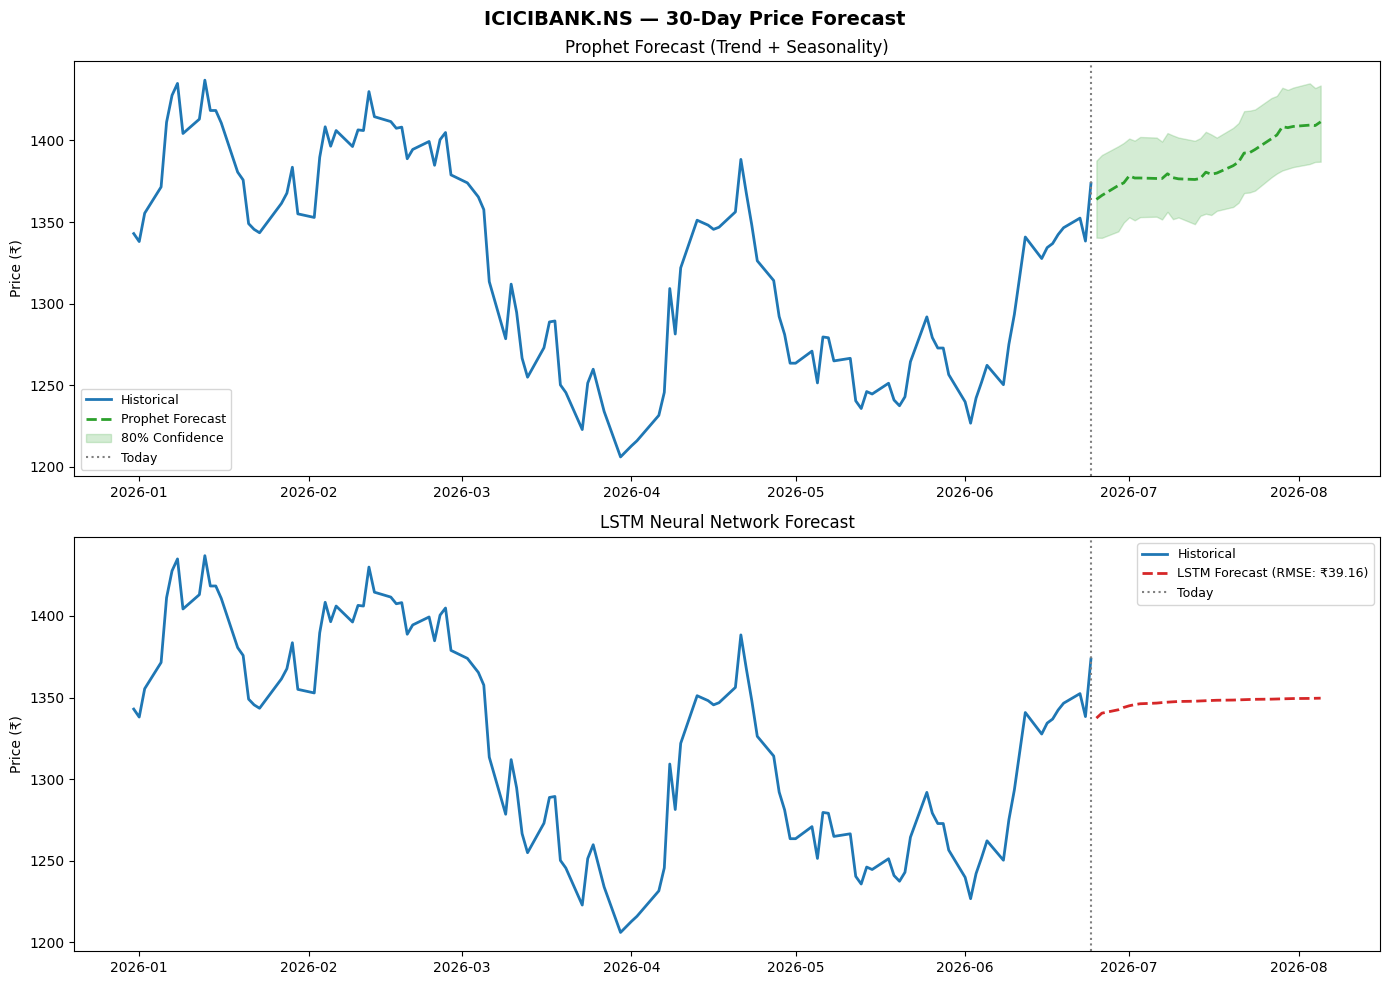

✅ Chart saved for ICICIBANK.NS


In [18]:
def plot_forecast_comparison(df, ticker, master_forecast, lstm_results):
    """Plot Prophet vs LSTM forecast comparison"""

    # Historical data
    stock_hist = df[df["Ticker"] == ticker].sort_values("Date").tail(120)

    # Prophet forecast
    prophet_fc = master_forecast[
        master_forecast["Ticker"] == ticker
    ].tail(30)

    # LSTM forecast
    lstm_fc = next(
        (r for r in lstm_results if r["ticker"] == ticker), None
    )

    fig, axes = plt.subplots(2, 1, figsize=(14, 10))
    fig.suptitle(f"{ticker} — 30-Day Price Forecast",
                 fontsize=14, fontweight="bold")

    # ── Plot 1: Prophet Forecast ──
    ax1 = axes[0]
    ax1.plot(stock_hist["Date"], stock_hist["Close"],
             label="Historical", color="#1f77b4", lw=2)
    ax1.plot(prophet_fc["Date"], prophet_fc["Forecast"],
             label="Prophet Forecast", color="#2ca02c",
             lw=2, ls="--")
    ax1.fill_between(
        prophet_fc["Date"],
        prophet_fc["Lower_CI"],
        prophet_fc["Upper_CI"],
        alpha=0.2, color="#2ca02c", label="80% Confidence"
    )
    ax1.axvline(stock_hist["Date"].max(),
                color="gray", ls=":", lw=1.5, label="Today")
    ax1.set_title("Prophet Forecast (Trend + Seasonality)")
    ax1.set_ylabel("Price (₹)")
    ax1.legend(fontsize=9)

    # ── Plot 2: LSTM Forecast ──
    ax2 = axes[1]
    ax2.plot(stock_hist["Date"], stock_hist["Close"],
             label="Historical", color="#1f77b4", lw=2)

    if lstm_fc:
        future_dates = pd.date_range(
            start=stock_hist["Date"].max(),
            periods=31, freq="B"
        )[1:]
        ax2.plot(future_dates, lstm_fc["predictions"],
                 label=f"LSTM Forecast (RMSE: ₹{lstm_fc['rmse']})",
                 color="#d62728", lw=2, ls="--")
        ax2.axvline(stock_hist["Date"].max(),
                    color="gray", ls=":", lw=1.5, label="Today")
    else:
        ax2.text(0.5, 0.5, "LSTM not run for this stock",
                 transform=ax2.transAxes, ha="center",
                 fontsize=11, color="gray")

    ax2.set_title("LSTM Neural Network Forecast")
    ax2.set_ylabel("Price (₹)")
    ax2.legend(fontsize=9)

    plt.tight_layout()
    plt.savefig(
        f"{BASE}/data/output/05_forecast_{ticker.replace('.NS','').replace('&','')}.png",
        dpi=150, bbox_inches="tight"
    )
    plt.show()
    print(f"✅ Chart saved for {ticker}")


# Plot for top 5 stocks
for ticker in LSTM_STOCKS:
    plot_forecast_comparison(df, ticker, master_forecast, lstm_results)

In [19]:
def build_forecast_summary(df, master_forecast):
    """Create a clean summary of all 30-day forecasts"""

    summary_rows = []

    for ticker in df["Ticker"].unique():
        # Latest actual price
        latest = df[df["Ticker"] == ticker].sort_values("Date").iloc[-1]
        current_price = latest["Close"]

        # Prophet 30-day forecast
        fc = master_forecast[master_forecast["Ticker"] == ticker]
        if fc.empty:
            continue

        forecast_30d = fc["Forecast"].iloc[-1]
        lower_30d    = fc["Lower_CI"].iloc[-1]
        upper_30d    = fc["Upper_CI"].iloc[-1]
        change_pct   = round(
            (forecast_30d - current_price) / current_price * 100, 2
        )

        summary_rows.append({
            "Ticker":           ticker,
            "Current_Price":    round(current_price, 2),
            "Forecast_30d":     round(forecast_30d, 2),
            "Lower_CI":         round(lower_30d, 2),
            "Upper_CI":         round(upper_30d, 2),
            "Expected_Change":  change_pct,
            "Direction":        "Bullish 📈" if change_pct > 0 else "Bearish 📉",
            "Forecast_Date":    datetime.today().strftime("%Y-%m-%d")
        })

    summary_df = pd.DataFrame(summary_rows).sort_values(
        "Expected_Change", ascending=False
    )

    print("📊 30-Day Forecast Summary (Top 15 Bullish):\n")
    print(summary_df[[
        "Ticker","Current_Price","Forecast_30d",
        "Expected_Change","Direction"
    ]].head(15).to_string(index=False))

    return summary_df


from datetime import datetime
forecast_summary = build_forecast_summary(df, master_forecast)

📊 30-Day Forecast Summary (Top 15 Bullish):

       Ticker  Current_Price  Forecast_30d  Expected_Change Direction
HINDUNILVR.NS        2157.80       2460.78            14.04 Bullish 📈
       UPL.NS         599.25        663.08            10.65 Bullish 📈
HEROMOTOCO.NS        4897.20       5397.92            10.22 Bullish 📈
ASIANPAINT.NS        2667.50       2882.14             8.05 Bullish 📈
ULTRACEMCO.NS       11430.00      12242.87             7.11 Bullish 📈
  JSWSTEEL.NS        1231.20       1300.89             5.66 Bullish 📈
       M&M.NS        3064.50       3237.39             5.64 Bullish 📈
  HDFCBANK.NS         793.20        831.50             4.83 Bullish 📈
      NTPC.NS         357.05        373.58             4.63 Bullish 📈
      BPCL.NS         315.70        326.86             3.54 Bullish 📈
APOLLOHOSP.NS        8573.50       8877.07             3.54 Bullish 📈
   SBILIFE.NS        1767.70       1822.65             3.11 Bullish 📈
 TATASTEEL.NS         190.16        196.03   

In [20]:
def save_forecast_data(master_forecast, forecast_summary):

    # Full forecast data
    master_forecast.to_parquet(
        f"{BASE}/data/processed/nifty50_forecasts.parquet", index=False
    )
    master_forecast.to_csv(
        f"{BASE}/data/output/nifty50_forecasts_powerbi.csv", index=False
    )
    print("✅ Full forecast data saved")

    # Summary table
    forecast_summary.to_csv(
        f"{BASE}/data/output/forecast_summary_powerbi.csv", index=False
    )
    print("✅ Forecast summary saved")

    print(f"\n📁 Files saved to Google Drive/data/output/:")
    print(f"   → nifty50_forecasts_powerbi.csv")
    print(f"   → forecast_summary_powerbi.csv")

save_forecast_data(master_forecast, forecast_summary)

✅ Full forecast data saved
✅ Forecast summary saved

📁 Files saved to Google Drive/data/output/:
   → nifty50_forecasts_powerbi.csv
   → forecast_summary_powerbi.csv


## ✅ Notebook 5 Complete!

**Save to GitHub:**
File → Save a copy in GitHub → `notebooks/05_forecasting.ipynb`
Commit message: `Add Notebook 5: Prophet + LSTM price forecasting for NIFTY 50`

**Next:** Notebook 6 — Portfolio Optimization (Efficient Frontier + Sharpe Ratio)